## Objetivo

O objetivo da feature engineering é transformar dados brutos em inputs (features) que maximizem o desempenho de um modelo de Machine Learning. Seus objetivos específicos são:

1. Melhorar o poder preditivo: o objetivo principal é criar novas variáveis ou transformar as existentes para que o modelo consiga captar relações complexas que não estavam óbvias nos dados originais;

2. Adequar os dados ao algoritmo: cada algoritmo tem premissas matemáticas diferentes. A engenharia de feature serve para "traduzir" os dados para o formato que o algoritmo entende (como transformar variáveis categóricas em numéricas);

3. Reduzir o Overfitting: features irrelevantes ou ruidosas confudem o modelo, fazendo com que ele decore os dados de treino em vez de aprender padrões gerais. A seleção de features mantem apenas as variáveis mais relevantes, removendo redundâncias (multicolinearidade) ou ruídos.

In [1]:
import sys 
import os 

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from src.data_cleaning import data_cleaning
from scipy.stats import f_oneway
import statsmodels.api as sm

In [3]:
df = pd.read_csv('../data/raw/train.csv', sep=',')

In [4]:
df = df.drop('Id', axis=1)

## 1. SalePrice

Como observado em 1_eda.ipynb, a variável SalePrice é right-skewed. Isso acontece porque a maioria dos imóveis possui preços conectrados em faixas menores. Assim, para que a distribuição da variável target se aproxime de uma distribuição normal, vamos realizar a transformação:

$$
    \text{SalePrice} = \log(\text{SalePrice})
$$

In [5]:
df['SalePrice'] = np.log1p(df['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

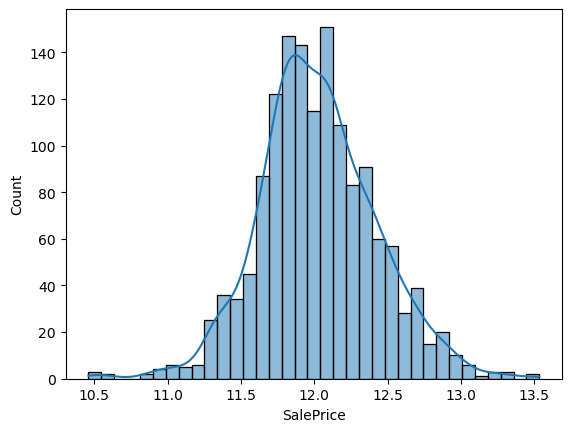

In [6]:
sns.histplot(df['SalePrice'], kde=True)

## 2. Limpando missing values

Vamos analisar o comportamento dos dados ausentes no dataset. Para isso, vamos calcular a porcentagem de dados ausentes em cada uma das colunas.

O primeiro passo é identificar quais colunas possuem dados ausentes:

In [7]:
missing_cols = df.columns[df.isna().sum() > 0]

missing_cols

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

E então calculamos a porcentagem relativa à aquela coluna:

In [8]:
missing_percent = (df[missing_cols].isna().sum() / len(df) * 100).sort_values(ascending=False)

missing_percent

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

A limpeza dos missing values será guiada pelos resultados de exploração em 1_eda.ipynb:

In [9]:
df = data_cleaning(df)

In [10]:
missing_cols = df.columns[df.isna().sum() > 0]

missing_cols

Index([], dtype='object')

In [11]:
missing_percent = (df[missing_cols].isna().sum() / len(df) * 100).sort_values(ascending=False)

missing_percent

Series([], dtype: float64)

Para realizar encoding das variáveis binárias:

In [12]:
def encode_binary(df):
    df = df.copy()

    binary_cols = {
        "CentralAir": {"N": 0, "Y": 1},
        "Street": {"Grvl": 0, "Pave": 1}
    }

    for col, mapping in binary_cols.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    return df

Para realizar encoding das variáveis nominais:

In [13]:
def encode_ordinal(df):
    df = df.copy()

    ordinal_mappings = {
        "ExterQual":   {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
        "ExterCond":   {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},

        "BsmtQual":    {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "BsmtCond":    {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},

        "KitchenQual": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
        "FireplaceQu": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "GarageQual":  {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "GarageCond":  {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},

        "PoolQC":      {"None": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
        "HeatingQC":   {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},

        "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},

        "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
        "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},

        "Functional": {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7},

        "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},

        "Fence": {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4},

        "LotShape": {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3},
        "LandSlope": {"Sev": 0, "Mod": 1, "Gtl": 2},

        "Alley": {"None": 0, "Grvl": 1, "Pave": 2}
    }

    for col, mapping in ordinal_mappings.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    return df

Para realizar one hot encoding das variáveis nominais:

In [ ]:
def one_hot_encode(train_df, test_df, nominal_cols):
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_encoded = pd.get_dummies(train_df, columns=nominal_cols, drop_first=False)
    test_encoded = pd.get_dummies(test_df, columns=nominal_cols, drop_first=False)

    train_encoded, test_encoded = train_encoded.align(
        test_encoded, join="left", axis=1, fill_value=0
    )

    return train_encoded, test_encoded

In [ ]:


# =========================
# 5. One-hot encoding das nominais
# =========================



# =========================
# 6. Aplicar os encodings
# =========================
train = encode_binary(train)
test = encode_binary(test)

train = encode_ordinal(train)
test = encode_ordinal(test)


nominal_cols = [
    "MSZoning",
    "LandContour",
    "Utilities",
    "LotConfig",
    "Neighborhood",
    "Condition1",
    "Condition2",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "Heating",
    "Electrical",
    "MiscFeature",
    "SaleType",
    "SaleCondition"
]

train_encoded, test_encoded = one_hot_encode(train, test, nominal_cols)


# =========================
# 7. Remover Id
# =========================
if "Id" in train_encoded.columns:
    train_encoded = train_encoded.drop(columns="Id")

if "Id" in test_encoded.columns:
    test_encoded = test_encoded.drop(columns="Id")


# =========================
# 8. Criar target transformada
# =========================
train_encoded["SalePrice_log"] = np.log(train_encoded["SalePrice"])


# =========================
# 9. Checagens finais
# =========================
print("\nShape train encoded:", train_encoded.shape)
print("Shape test encoded:", test_encoded.shape)

print("\nColunas object restantes no train:")
print(train_encoded.select_dtypes(include="object").columns.tolist())

print("\nColunas object restantes no test:")
print(test_encoded.select_dtypes(include="object").columns.tolist())

print("\nMissing values restantes no train encoded:")
print(train_encoded.isnull().sum()[train_encoded.isnull().sum() > 0].sort_values(ascending=False).head(20))

print("\nMissing values restantes no test encoded:")
print(test_encoded.isnull().sum()[test_encoded.isnull().sum() > 0].sort_values(ascending=False).head(20))


# =========================
# 10. Separar X e y
# =========================
X = train_encoded.drop(columns=["SalePrice", "SalePrice_log"])
y = train_encoded["SalePrice_log"]

print("\nShape X:", X.shape)
print("Shape y:", y.shape)

X.head()

## Classificação das colunas por tipo

Grupo de variáveis relacionadas a área / dimensões:

- LotArea: tamanho da propriedade
- MasVnrArea: área de revestimento de alvenaria
- GrLivArea: área habitável acima do solo 
- GarageArea: tamanho da garagem 
- PoolArea: tamanho da piscina
- BsmtFinSF2: área construída do tipo 2
- BsmtUnfSF: área inacabada do porão
- TotalBsmtSF: área total do porão 
- 1stFlrSF: metragem (em pés quadrados) do primeiro piso 
- 2ndFlrSF: metragem em pés quadrados do segundo piso 
- WoodDeckSF: área do deck de madeira em pés quadrados
- OpenPorchSF: varanda aberta (em pés quadrados)
- EnclosedPorch: varanda fechada (em pés quadrados)
- 3SsnPorch: varanda de três estações (em pés quadrados)
- ScreenPorch: varanda tela (em pés quadrados)
- BedroomAbvGrv: quantidade de quartos acinma do nível do solo
- BldgType: tipo de habitação
- KitchenAbvGrv: cozinhas quantidade de cozinhas acima do nível do solo
- TotRmsAbvGrd: quantidade total de quartos acima do nível do solo

Grupo de variáveis relacionadas a qualidade / condição:

- OverallQual: avaliação do material e acabamento geral da casa
- OverallCond: avaliação do estado geral da casa
- ExterQual: qualidade do material no exterior
- ExterCond: estado atual do material no exterior
- HeatingQC: condição da qualidade do sistema de aquecimento
- LowQualFinSF: baixa qualidade da área construída
- FireplaceQu: qualidade das lareiras
- GarageQual: qualidade da garagem
- PoolQC: qualidade da piscina
- Fence: qualidade da cerca
- Exterior1st: cobertura externa da casa
- Exterior2st: cobertura externa da casa se houver mais de uma
- Foundation
- HouseStyle
- KitchenQual: qualidade da cozinha
- MSSubClass: identifica o tipo de imóvel envolvido na venda
- MasVnrType: tipo de revestimento de alvenaria

Grupo de variáveis relacionadas a localização:

- MSZoning: identifica a classificação geral de zoneamento da área de venda
- LotFrontage: metros lineares de rua conectados à propriedade
- Street: tipo de acesso rodoviário à propriedade
- Alley: tipo de acesso ao imóvel pelo beco
- Neighborhood: localização física dentro dos limites da cidade de Ames
- Condtion1: proximidade de determinadas condições
- Condition2: proximidade de determinadas condições se houver mais de uma 
- LotShape: formato do terreno do imóvel 
- LandContour: planicidade da propriedade
- LotConfig: configuração do lote (se é de esquina, sem saída, ...)
- LandSlope: inclinação do terreno

Grupo de variáveis relacionadas a garagem:

- GarageType: localização da garagem
- GarageYrBlt: ano em que a garagem foi construída
- GarageFinish: interior da garagem finalizado
- GarageCars: quantidade de carros que cabem na garagem
- GarageArea: tamanho da garagem em pés quadrados
- GarageQual: qualidade da garagem
- GarageCond: condição da garagem

Grupo de variáveis relacionadas ao porão:

- BsmtQual: avalia a altura do porão
- BsmtCond: avalia a condição do porão
- BsmtExposure: refere-se a paredes com saída para o exterior ou ao nível do jardim
- BsmtFinType1: classificação da área acabada do porão
- BsmtFinSF1: tamanho em pés quadrados do tipo 1
- BsmtFinType2: classificação da área acabada do porão (se houver vários tipos)
- BsmtFinSF2: área construída do tipo 2
- BsmtUnfSF: área em pés quadrados inacabada do porão
- TotalBsmtSF: área total do porão em pés quadrados
- BsmtFullBath: banheiros completos no porão
- BsmtHalfBath: lavabos completos no porão

Grupo de variáveis relacionadas a utilidades:

- Heating
- HeatingQC
- CentralAir
- Eletrical
- Functional
- Fireplaces 
- PavedDrive
- PoolQC
- Fence
- MiscFeature
- MiscVal
- Utilities

Grupo de variáveis relacionadas a piscina:

- PoolArea: área da piscina 
- PoolQC: qualidade da piscina

Grupo de variáveis relacionadas ao telhado:

- RoofStyle: tipo de telhado
- RoofMatel: material do telhado

Grupo de variáveis relacionadas a idade:

- MoSold: mês da venda
- YrSold: ano da venda
- GarageYtBlt: ano em que a garagem foi construída
- YearBuilt: ano de construção original da casa
- YearRemodAdd: ano de recuperação ou adição de cômodos na casa

Grupo de variáveis relacionadas a banheiro:

- Banheiros completos no porão
- BsmtHalfBath: lavabos no porão
- FullBath: banheiros completos acima do nível do solo
- HalfBath: lavabos acima do nível do solo

Grupo de variáveis relacionadas a venda:

- SaleCondition
- SaleType

## 1. SalePrice

Como visto na análise exploratória dos dados (EDA - 1_eda.ipynb), a variável alvo SalePrice é right-skewed, assim, é interessante que apliquemos o logartimo no dataset para normaliza-lo.

Para decidir como tratar esses dados, precisamos entendê-los. No arquivo README.md, na pasta data, há uma descrição breve (mas suficiente) do que cada uma dessas colunas significam. Ao observa-lo, concluímos que grande parte dos das ausentes não significam dados faltantes, mas sim ausência da característica na casa.

| Variável | Como tratar missing values |
|----------|----------------------------|
| PoolQC | A grande quanidade de dados ausentes representa casas que não possuem piscina, substituir por "None"|
| MiscFeature | A residência não possui características não explicadas pelas outras variáveis, substituir por "None"|
| Alley | A residência não possui acesso a beco, substituir por "None" | 
| Fence | A residência não possui cercas, substituir por "None" |
| MasVnrType | A residência não possui revestimento de alvenaria, substituir por "None" | 
| FireplaceQu | A residência não possui lareira, substituir por "None" |
| LotFrontage | Não há informação do comprimento da rua conectada ao lote; pode ser estimado pela mediana do bairro (Neighborhood) |
| GarageType | A residência não possui garagem, substituir por "None"|
| GarageYrBlt | Não há informação sobre data de construção da garagem, substituir pelo mesmo ano de criação da casa (YearBuilt)| 
| GarageFinish | A residência não possui garagem, substituir por "None"| 
|GarageQual| A residência não possui garagem, substituir por "None"| 
|BsmtExposure| A residência não possui porão, substituir por "None"|
|BsmtFinType1| A residência não possui acabamento no porão, substituir por "None"|
|BsmtFinType2| A residência não possui segundo tipo de acabamento no porão, substituir por "None"|
|BsmtQual| A residência não possui porão, substituir por "None"|
|BsmtCond | A residência não possui porão, substituir por "None"| 
| BsmntFinType1 | A residência não possui acabamento principal no porão, substituir por "None"|
|MasVnrArea| Se MasVnrType = None, então MasVnrArea = 0|
| Electrical | Poucos valores faltantes, substituir pela moda| 


## 1. Variáveis categóricas

Agora, vamos analisar como as variáveis categóricas influenciam no target SalePrice. Para isso, o primeiro passo é identificá-las:

In [ ]:
cat_cols = list(df.select_dtypes(include=["object", "category"]).columns)

for col in cat_cols:
    print(col, df[col].nunique())

In [ ]:
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print()

### 3.1 Variáveis ordinais

As variáveis: 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC' e 'HeatingQC' são variáveis ordinais, onde cada uma das siglas significam:

| Sigla | Significado| 
|-------|-----------|
|Ex | Excellent |
|Gd | Good |
|TA | Typical/Average|
|Fa| Fair| 
|Po | Poor |

Assim, a ordem natural é Po < Fa < TA < Gd < Ex.

A variável 'BsmtExposure' também é ordinal e representa o nível de exposição do porão e suas siglas significam:

| Sigla | Significado |
|-------|-------------|
|No | Sem exposição (porão interno, sem janelas) |
|Mn | Exposição mínima (pouca luz/ventilação)| 
| Av | Exposição média (alguma luz/ventilação)|
| Gd | Exposiçã ótima/boa (muito ventilado ou iluminado)|
| Na/NaN | Sem porão |

As variáveis 'BsmtFinType1' e 'BsmtFinType2' também são ordinais e relacionam-se à qualidade do porão. Suas siglas significam:

| Sigla | Significado |
|-------|--------------|
| Unf | Inacabado |
|LwQ | Acabamento de baixa qualidade (Low Quality)|
| Rec | Sala de recreação (adequado, mas simples)|
| BLQ | Basement Low Quality / parcialmente acabado|
| ALQ | Basement Average / bom acabamento| 
| GLQ | Basement Good / excelente acabamento (Good Living Quarters)|
| Na/NaN | Sem porão |

A variável 'Functional' também é ordinal e representa a funcionalidade da casa. Suas siglas significam:

| Sigla | Significado | 
|-------|-------------|
| Sal | Severely irregular (planta muito ruim)| 
| Sev | Severely irregular| 
| Maj2 | Maior problema 2 (algum defeito estrutural ou planta estranha)| 
| Maj1 | Maior problema 1| 
| Mod | Moderadamente funcional| 
| Min2 | Pequeno problema 2| 
| Min1 | Pequeno problema 1| 
| Typ | Typical / Normal (sem problemas)|
| Na/NaN | Não informado |

A variável 'GarageFinish' também é ordinal e representa a finalização da garagem. Suas siglas significam:

| Sigla | Significado |
|------|--------------|
| Unf | Não acabada | 
| RFn | Semi-acabada/Raw finish| 
| Fin | Totalmente acabada|
| Na/NaN | Sem garagem | 

A variável 'Fence' também é ordinal e representa a qualidade da cerca. Suas siglas significam:

| Sigla | Significado| 
|-------|------------|
| MnWw | Madeira de baixo custo| 
| GdWo | Madeira boa|
| MnPrv | Minimamente construída, privativa| 
| GdPrv | Bem construída, privativa|
| Na/NaN | Sem cerca |

## Variáveis binárias 

A variável 'CentralAir' é uma variável binária, onde 

| Sigla | Significado | 
|-------|-------------|
| Y | Sim |
| N | Não |

In [ ]:
df["CentralAir"] = df["CentralAir"].map({"N": 0, "Y": 1})

As variáveis 'Street' e 'Alley' são binárias, e suas siglas são:

| Sigla | Significado |
|-------|-------------|
| Paved | Pavimentada | 
| Grvl| Cascalho | 
| None/NaN | Não informado|

In [ ]:
df["Street"] = df["Street"].map({"Grvl": 0, "Paved": 1}).fillna(0)
df["Alley"] = df["Street"].map({"Grvl": 0, "Paved": 1}).fillna(0)

As variáveis 'MSZoning', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1/Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RooftMatl', 'Exterior1st/Exterior2nd', 'MasVnrType', 'Heating', 'Electrical', 'MiscFeature', 'SaleType' e 'SaleCondition' são variáveis nominais e serão tratadas com one-hot encoding.

In [ ]:
nominal_cols = ["MSZoning", "LotShape", "LandContour", "Utilities", "LotConfig", "LandSlope",
                "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle",
                "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd",
                "MasVnrType", "Heating", "Electrical", "MiscFeature", "SaleType",
                "SaleCondition"]

df[nominal_cols] = df[nominal_cols].fillna("None")

In [ ]:
for col in nominal_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=col, y='SalePrice', data=df)
    plt.xticks(rotation=45)
    plt.title(f'SalePrice por {col}')
    plt.show()

In [ ]:
for col in nominal_cols:
    groups = [df[df[col]==cat]['SalePrice'] for cat in df[col].unique()]
    f_stat, p_val = f_oneway(*groups)
    print(col, 'p-value:', p_val)